# **OBLW - 02: Zscore Statistics**

Analysis of the target series `scripts/targets/OBLW/02_offline.jl`:
- **Training data:** 4 trajectories of one year each (daily), started from the training restarts (runs 2-3). Trajectories 1-3 are used for training, trajectory 4 for validation.
- **Correlation:** how strongly the outputs (dT, OLW, SLWD) follow the temperature predictors of the Linear (T) and Planck (T⁴) output forms.
- **Zscore:** distributions of all input and output fields, and of the per-column output form fits, from which the zscore statistics are taken (all 4 trajectories, the validation trajectory included).

Generated by (derive task 0: `steps = (:column_io, :zscore)`):
- `data/column_io/OBLW/training_data/column_io.jld2`
- `data/zscore/OBLW/default/`: `zscore.jld2`, `coeffs.jld2` (the per-column fits)

The histograms are saved to `data/zscore/OBLW/default/plots_distribution/`.

## **0. Setup**

In [1]:
# Load packages
using Revise
using NeuralLongwave

In [23]:
# Column IO dataset, zscore statistics and the per-column output form fits
column_io = NeuralLongwave.load(; dir = column_io_dir("OBLW", "training_data"), file = "column_io.jld2")
zs        = NeuralLongwave.load(; dir = zscore_dir("OBLW", "default"),          file = "zscore.jld2")
coeffs    = NeuralLongwave.load(; dir = zscore_dir("OBLW", "default"),          file = "coeffs.jld2");

## **1. Correlation**

### 1.1. Temperature Tendencies

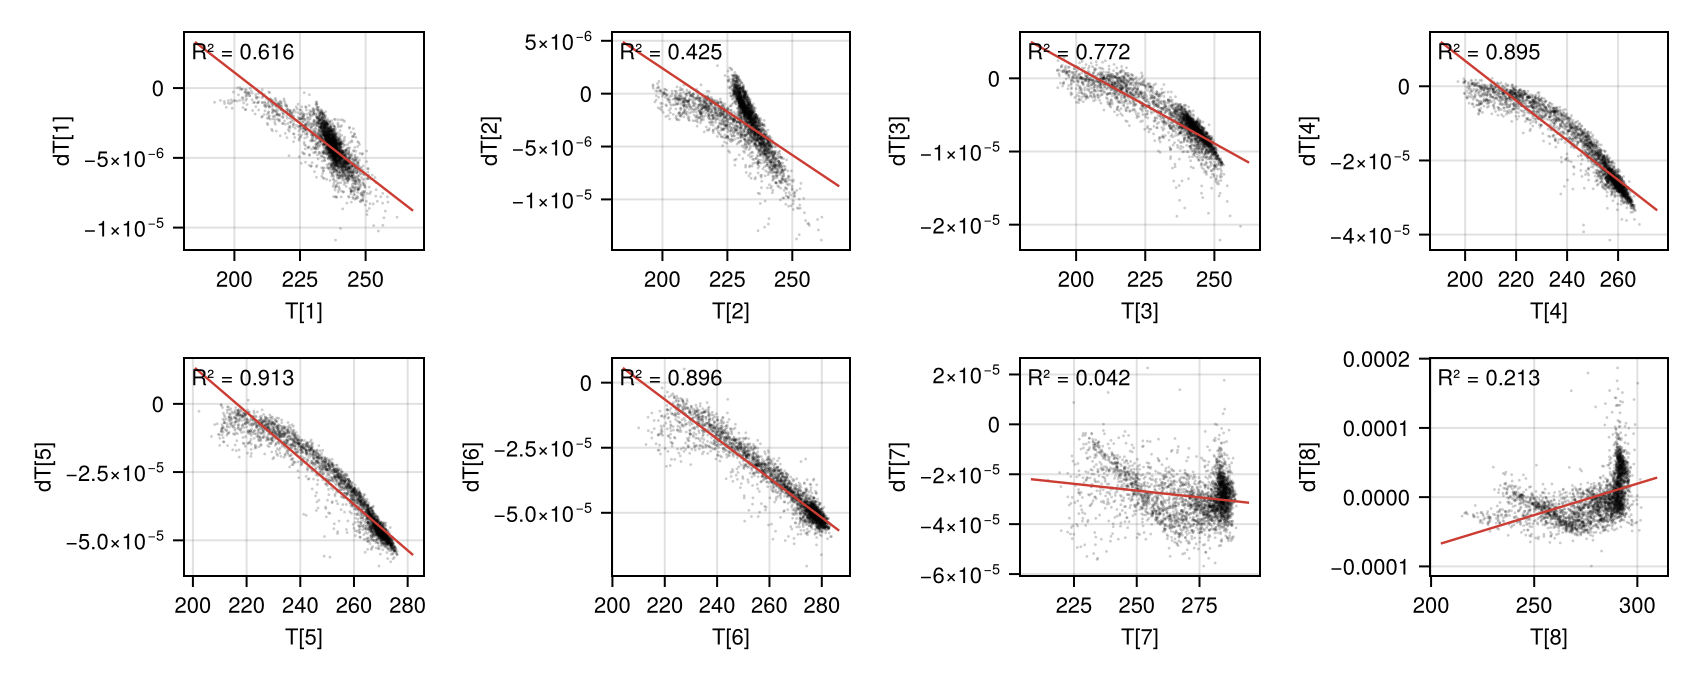

In [3]:
# Linear: dT vs T
plot_correlation(fields, :dT, :T; output_form = LinearOutput())

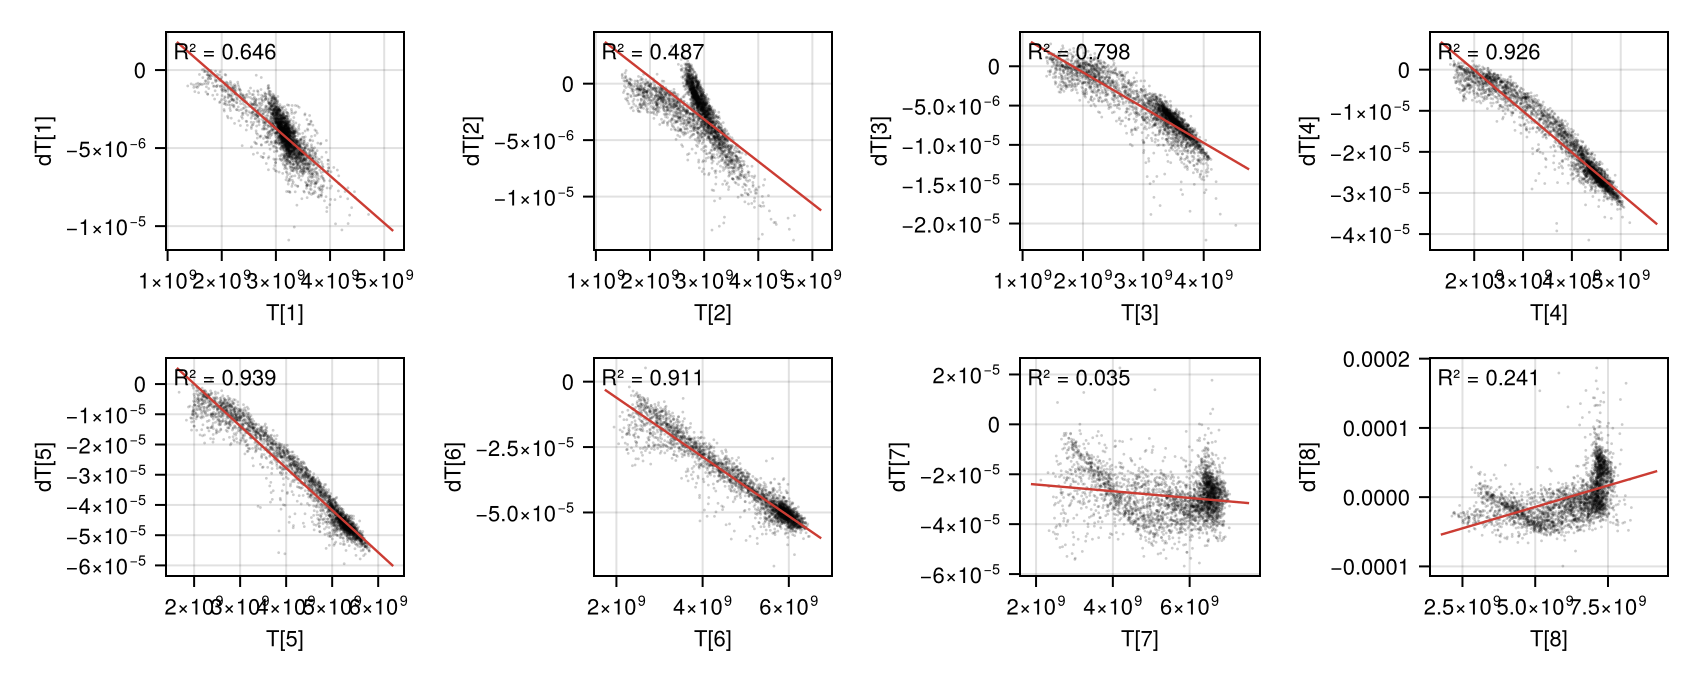

In [4]:
# Planck: dT vs T
plot_correlation(fields, :dT, :T; output_form = PlanckOutput())

### 1.2. Outgoing Longwave

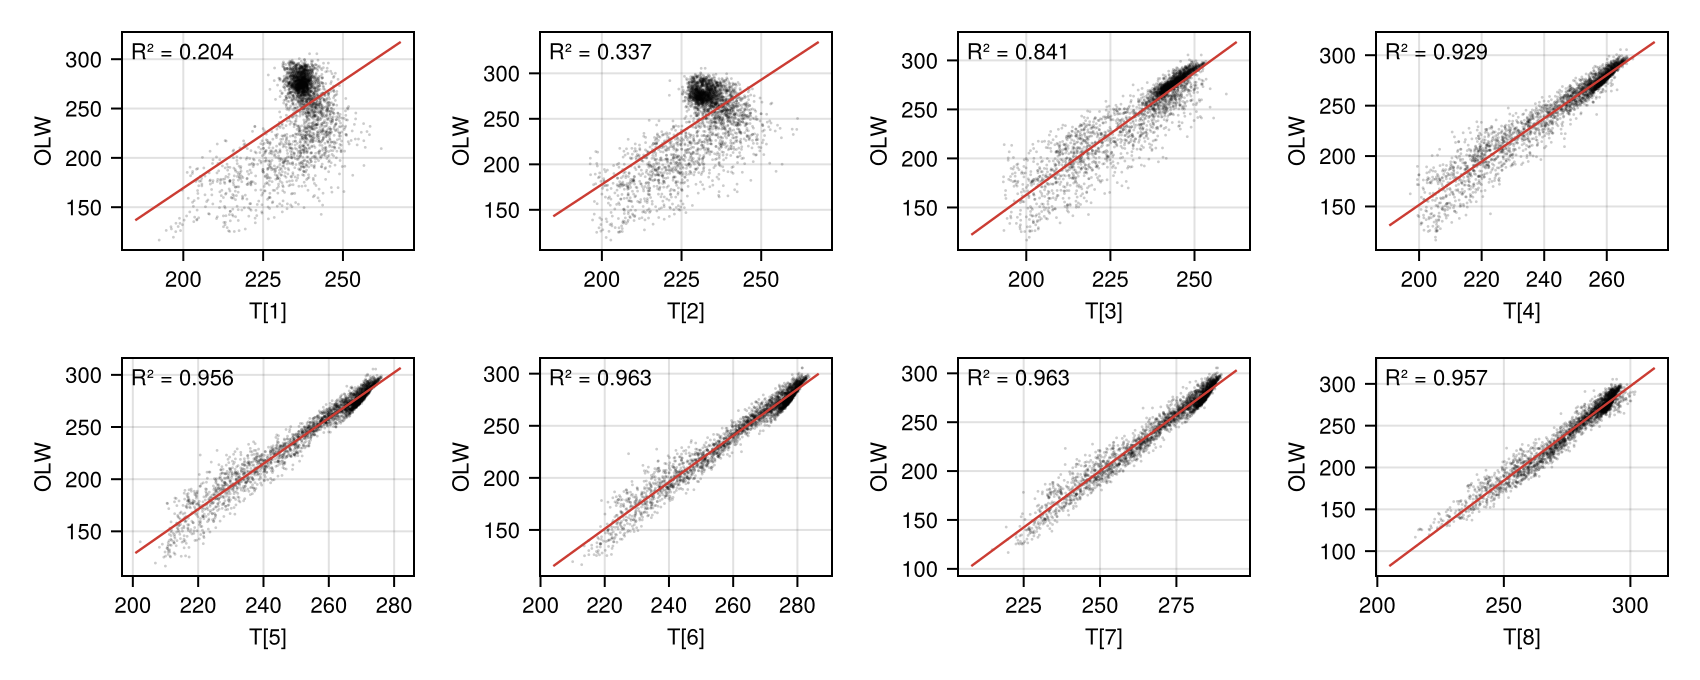

In [5]:
# Linear: OLW vs T
plot_correlation(fields, :olw,  :T; output_form = LinearOutput())

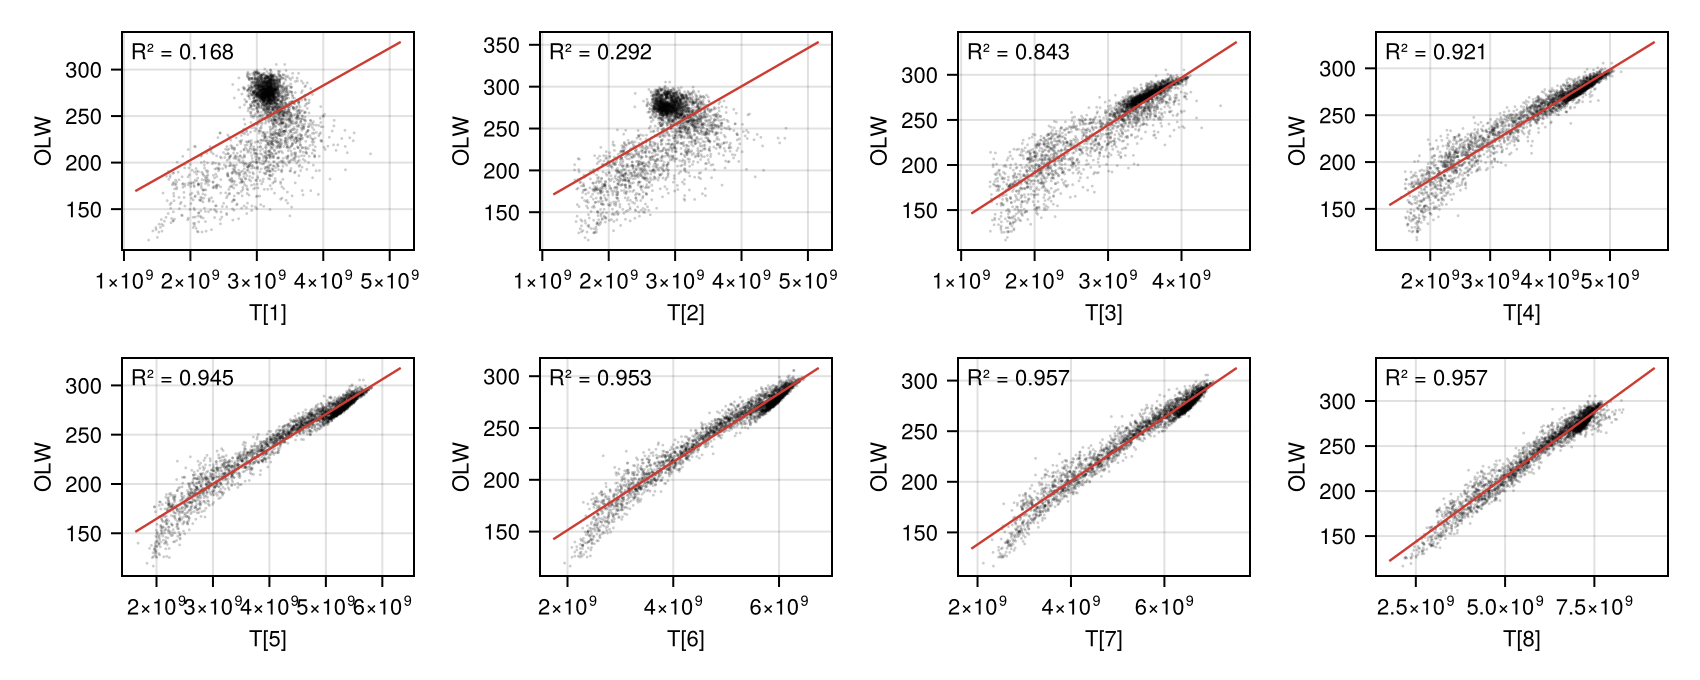

In [6]:
# Planck: OLW vs T profile
plot_correlation(fields, :olw,  :T; output_form = PlanckOutput())

### 1.3. Surface Longwave Down

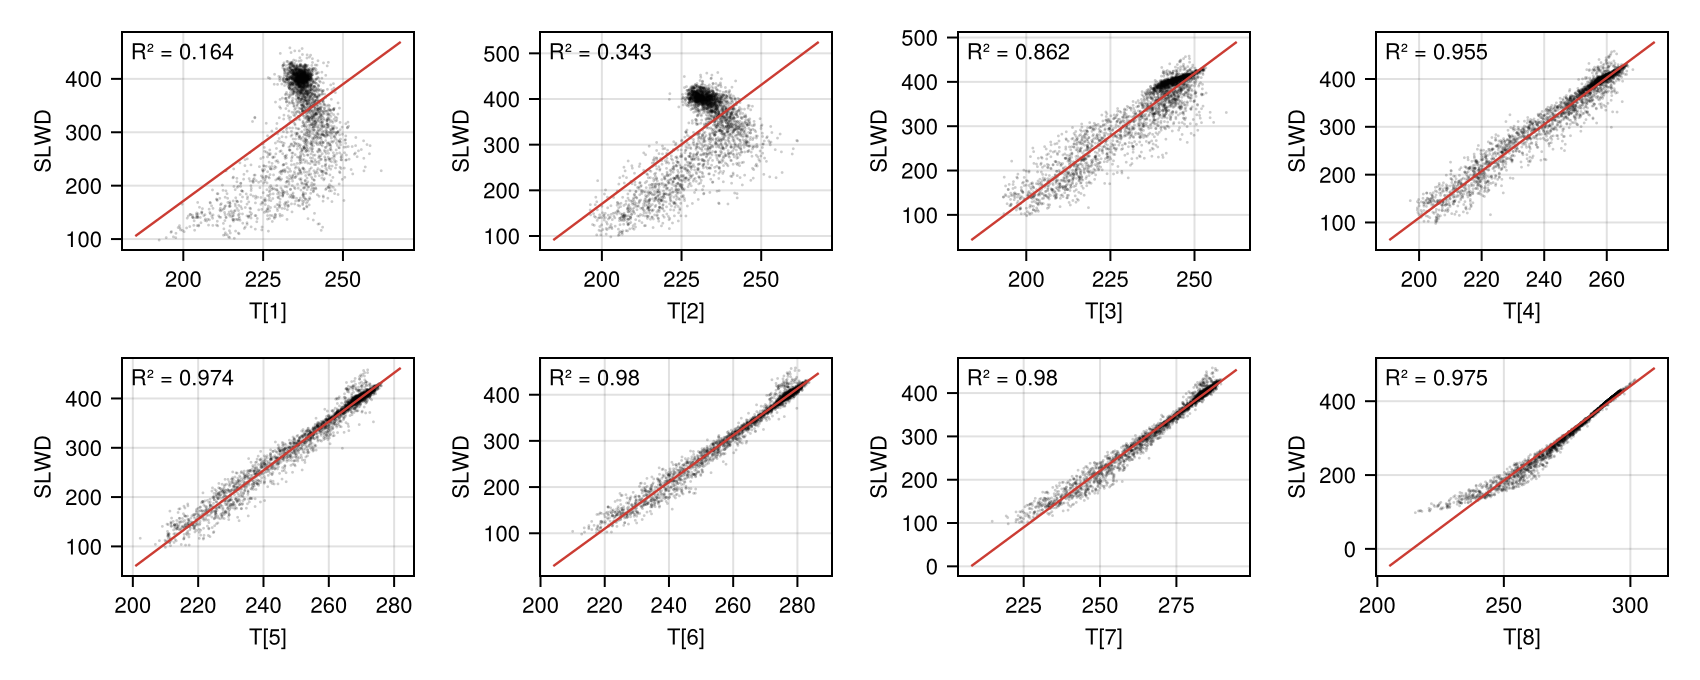

In [7]:
# Linear: SLWD vs T profile
plot_correlation(fields, :slwd, :T; output_form = LinearOutput())

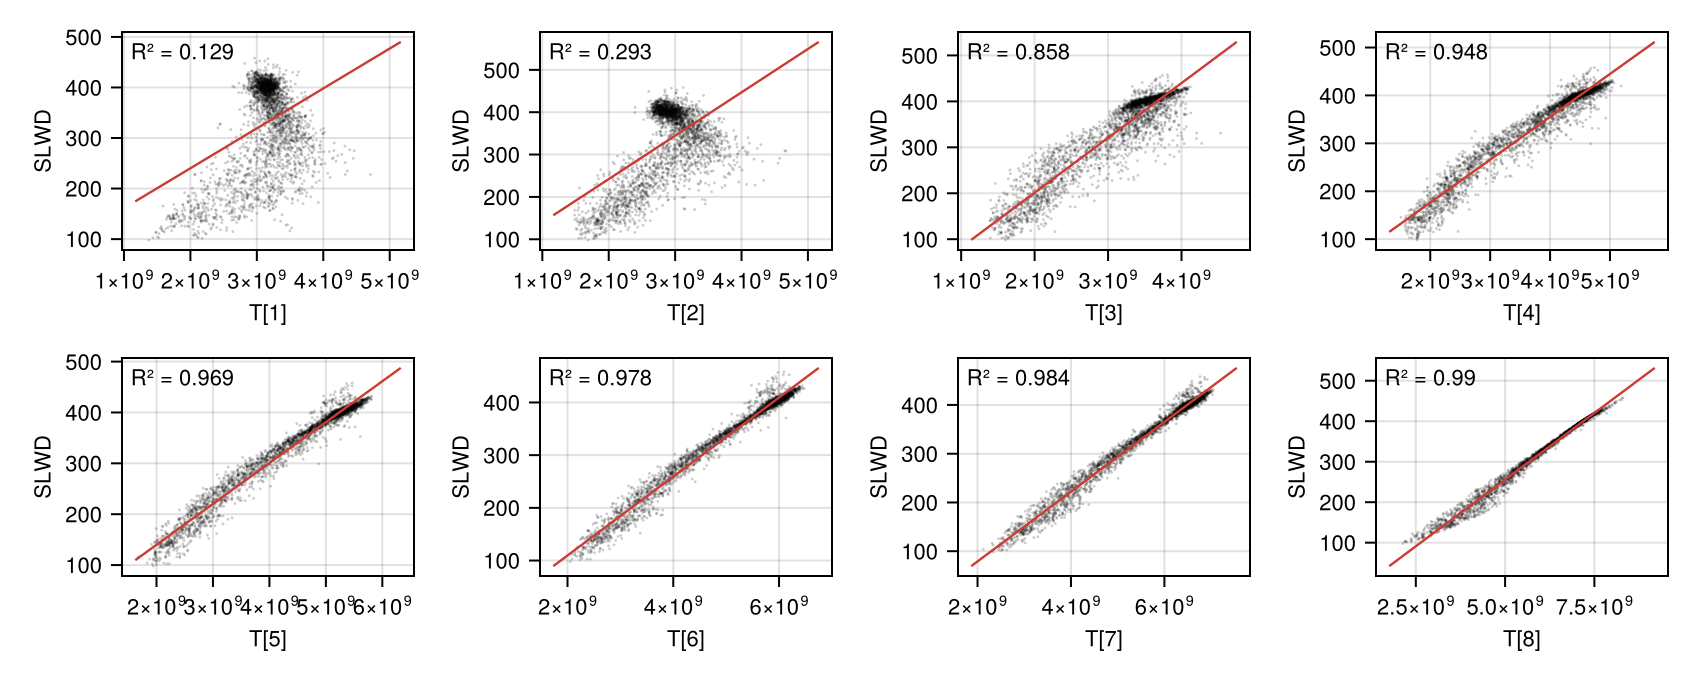

In [8]:
# Planck: SLWD vs T profile
plot_correlation(fields, :slwd,  :T; output_form = PlanckOutput())

## **2. Zscore Histograms**

### 2.1. IO

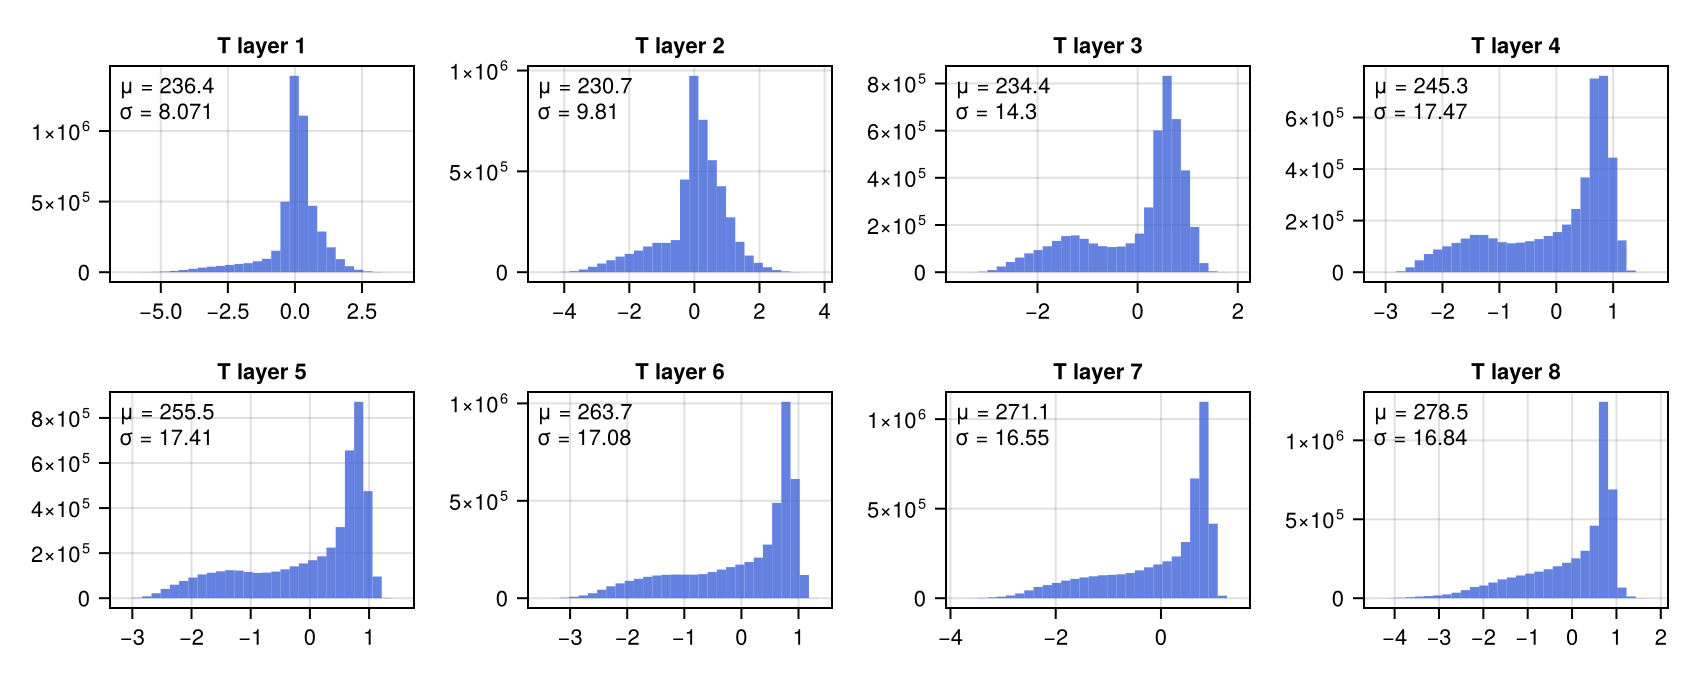

In [24]:
# Temperature
h_T = plot_hist(column_io.fields, zs.fields, (:T))

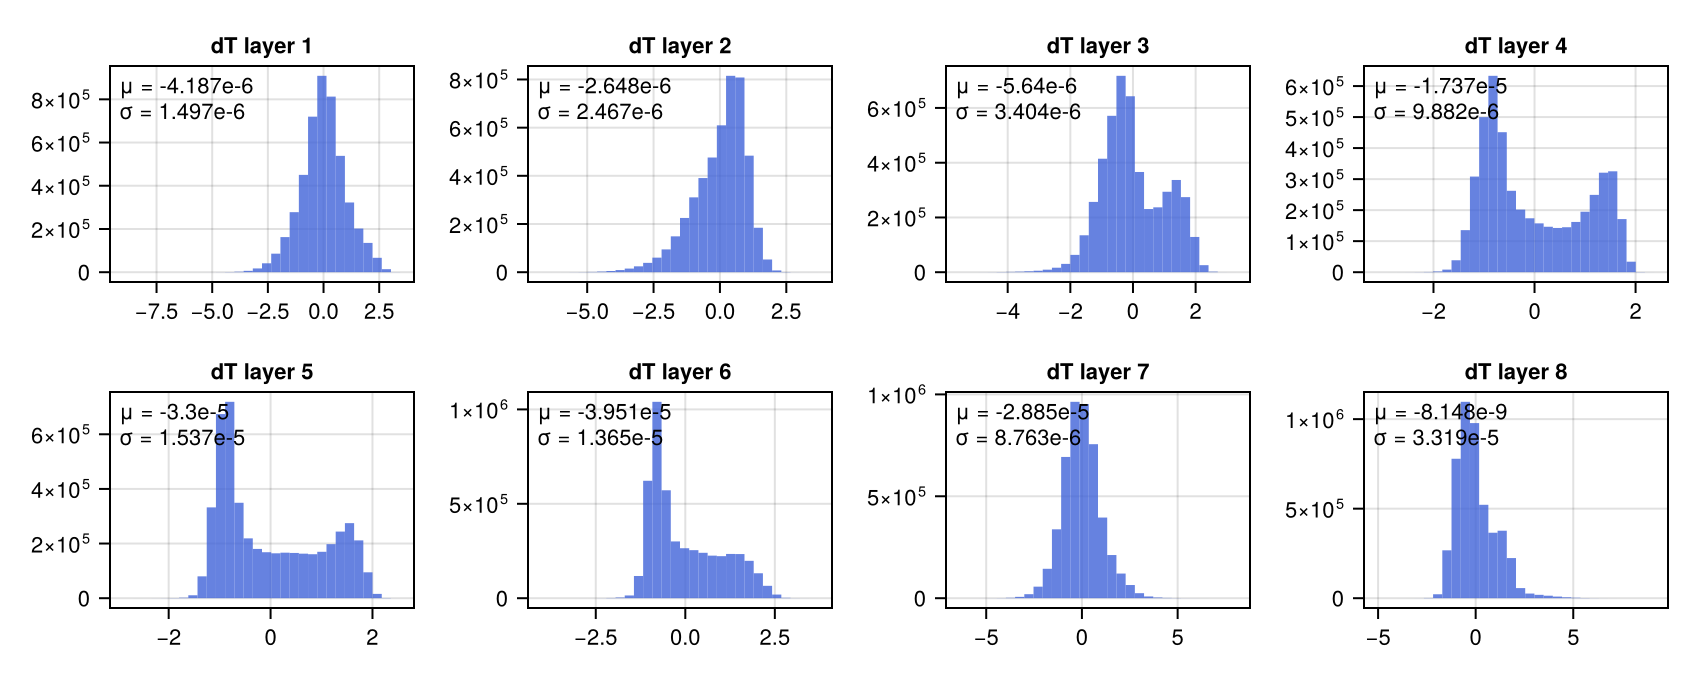

In [25]:
# Temperature tendencies
h_dT = plot_hist(column_io.fields, zs.fields, (:dT))

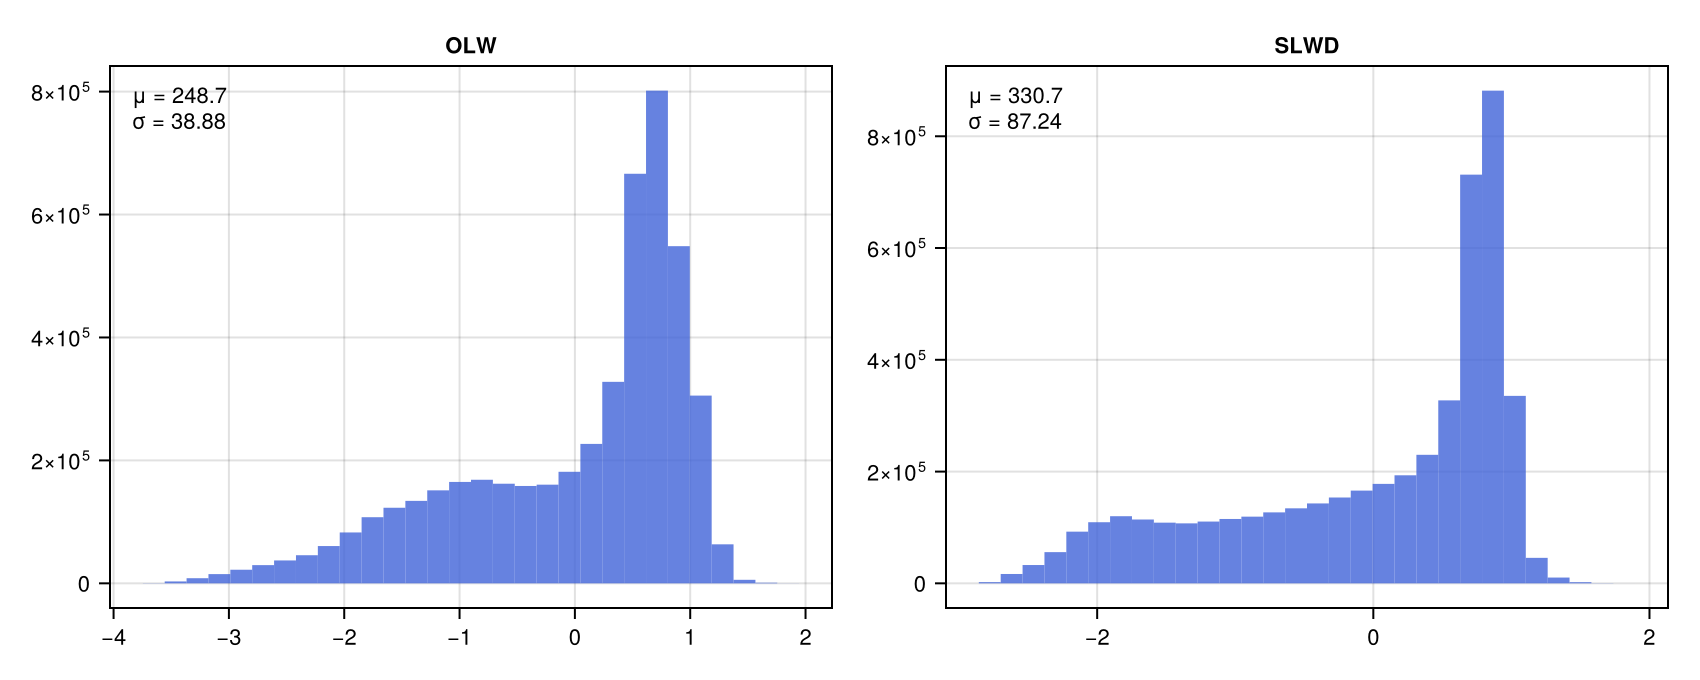

In [26]:
# Fluxes
h_flux = plot_hist(column_io.fields, zs.fields, (:olw, :slwd))

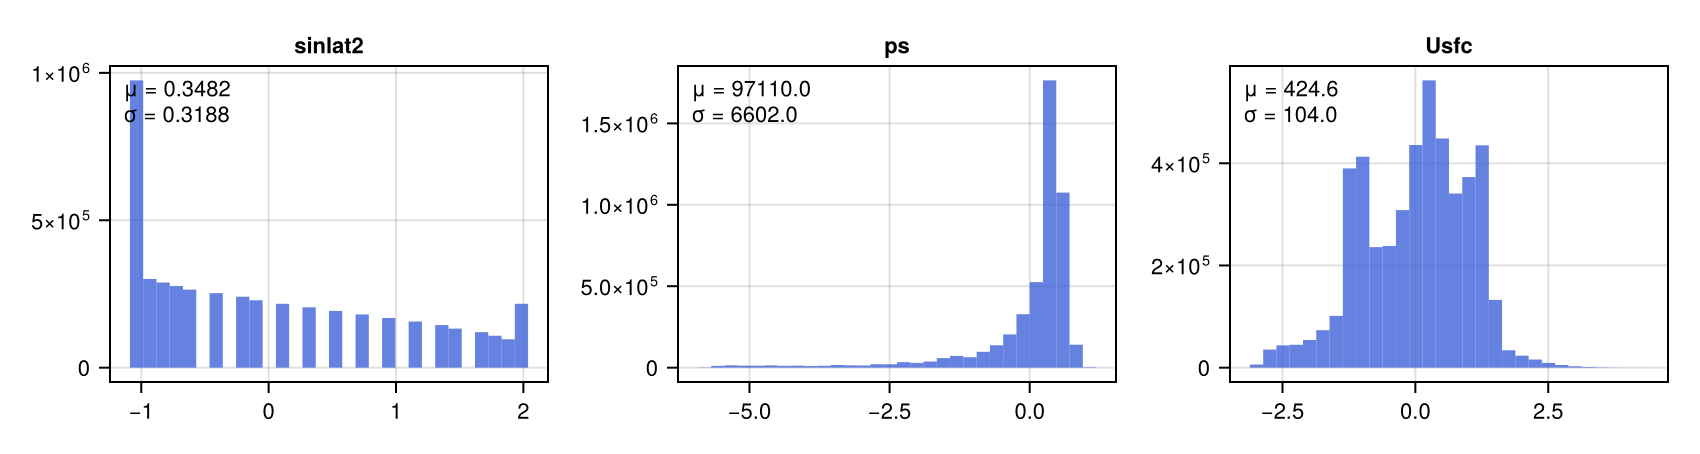

In [27]:
# Input scalars
h_scalar = plot_hist(column_io.fields, zs.fields, (:sinlat2, :ps, :Usfc))

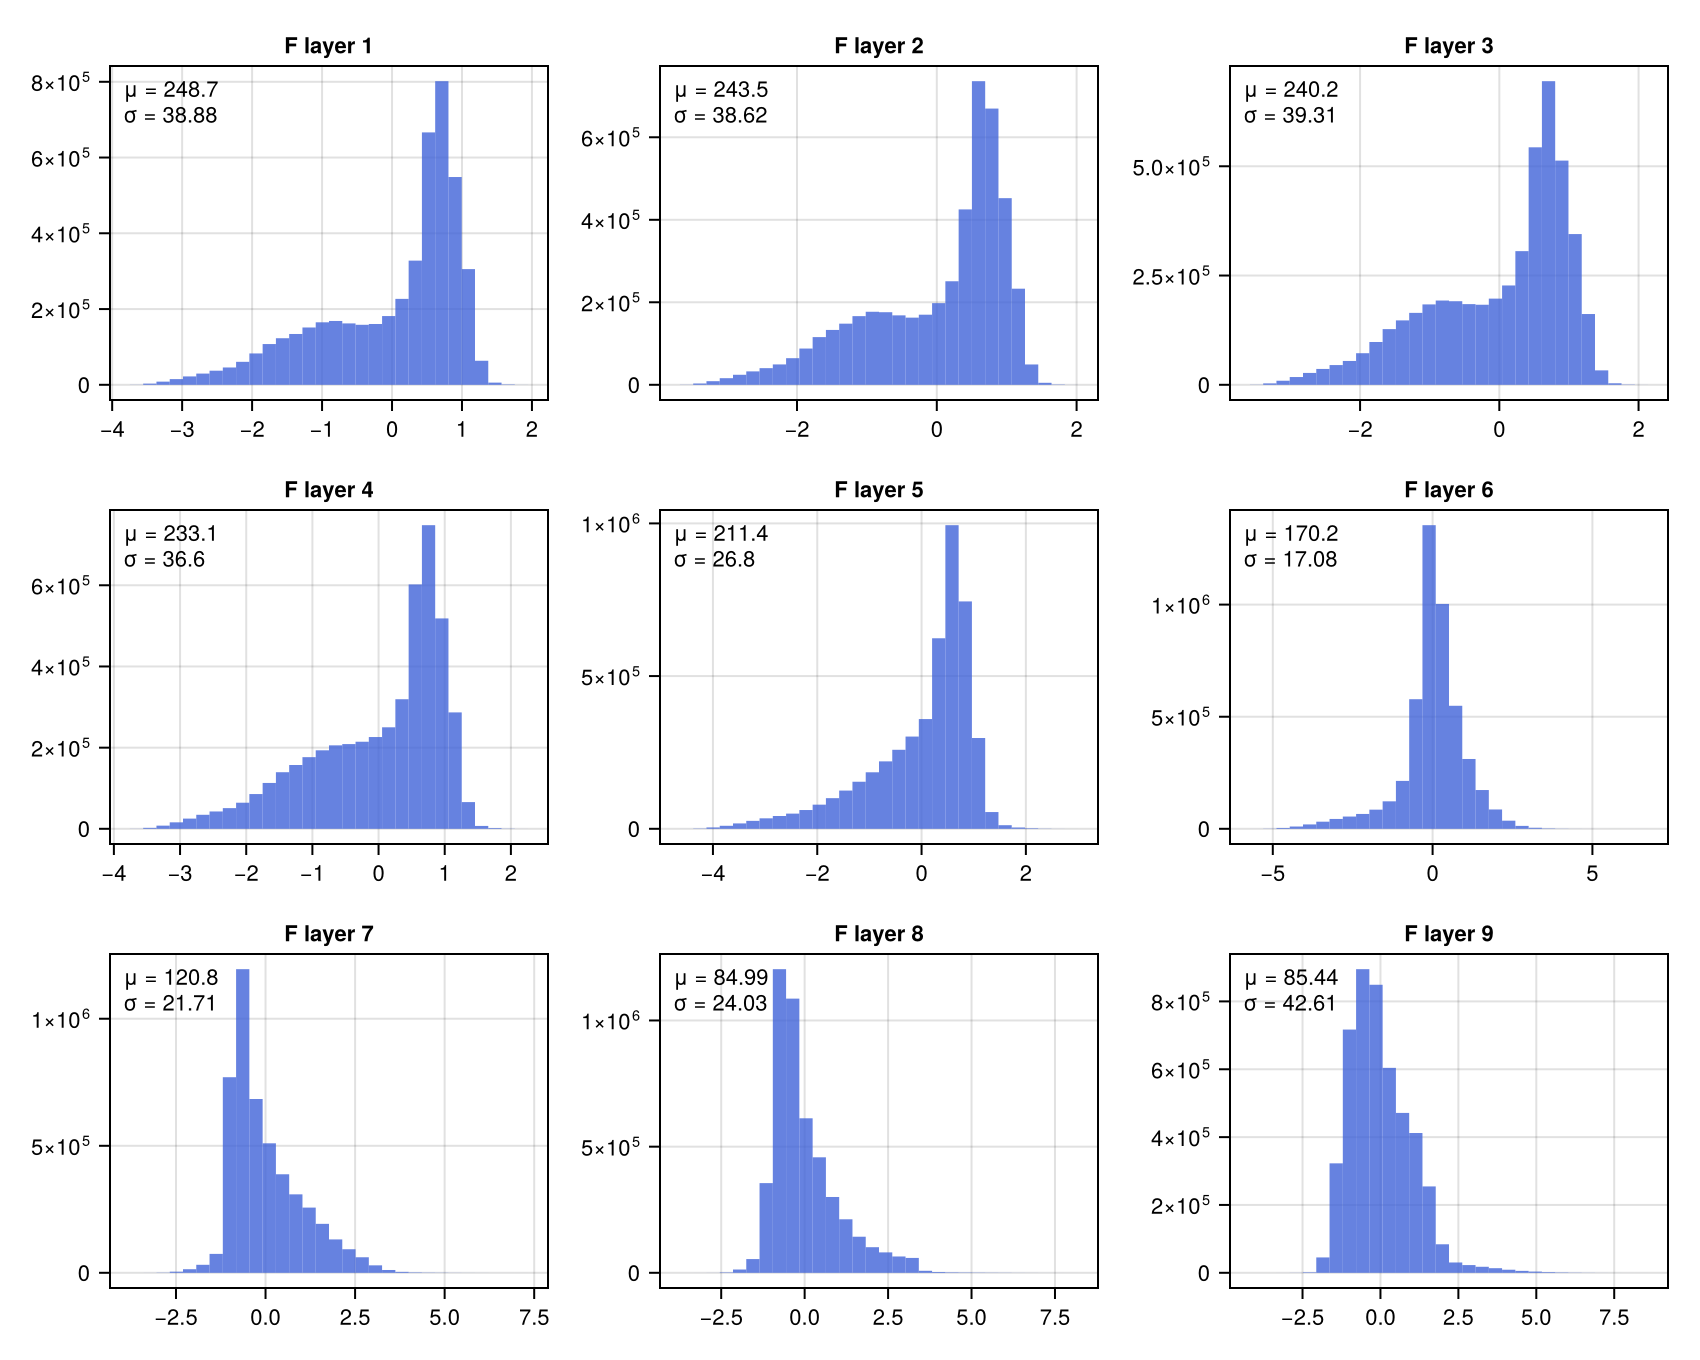

In [28]:
# Net fluxes at layer interfaces
h_net_fluxes = plot_hist(column_io.fields, zs.fields, (:F), style=(;ncols=3))

### 2.2. Outputform Coefficients

#### 2.2.1. Temperature

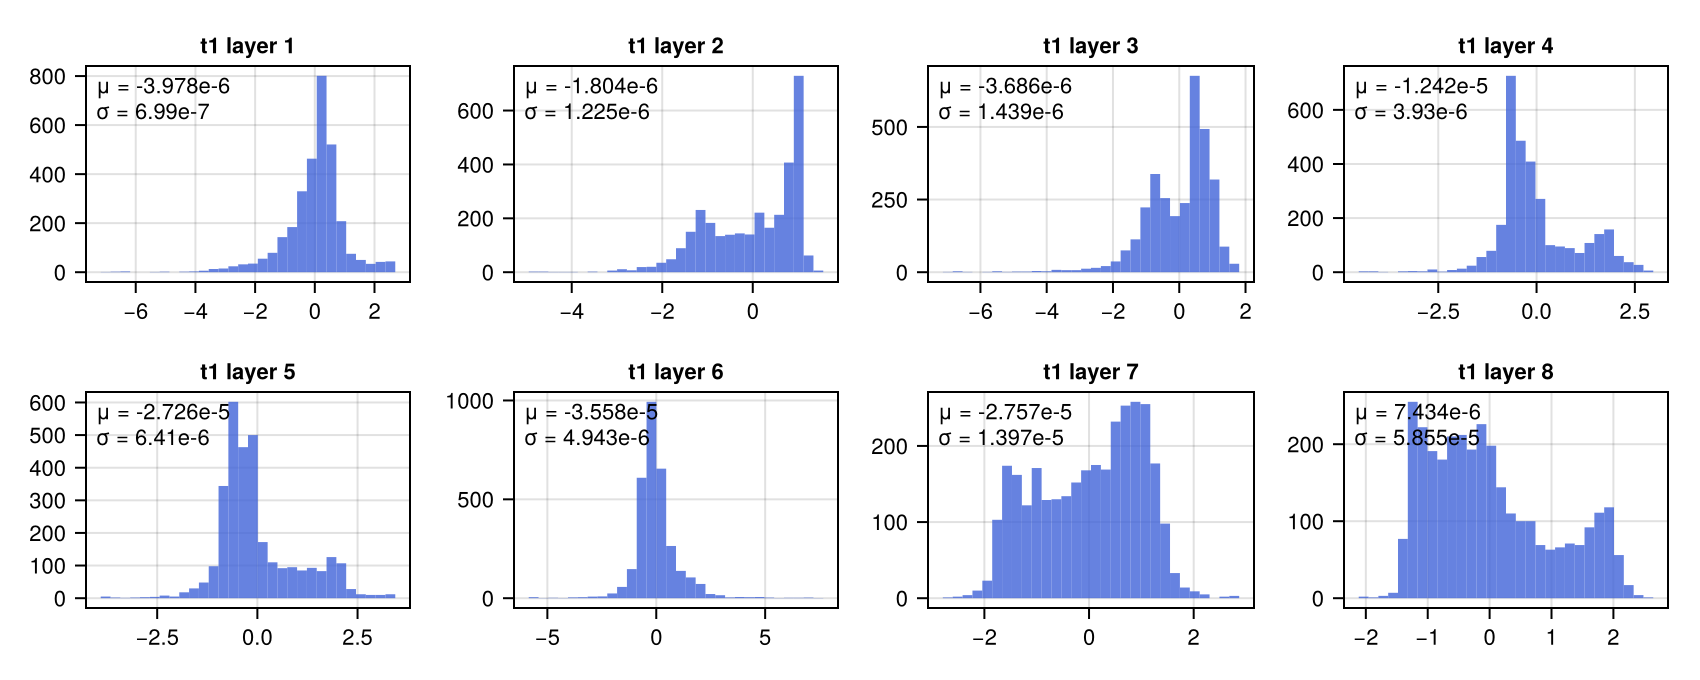

In [29]:
# Linear: Temperature, constant terms
h_t1_linear = plot_hist(coeffs.linear.coeffs, zs.linear, (:t1))

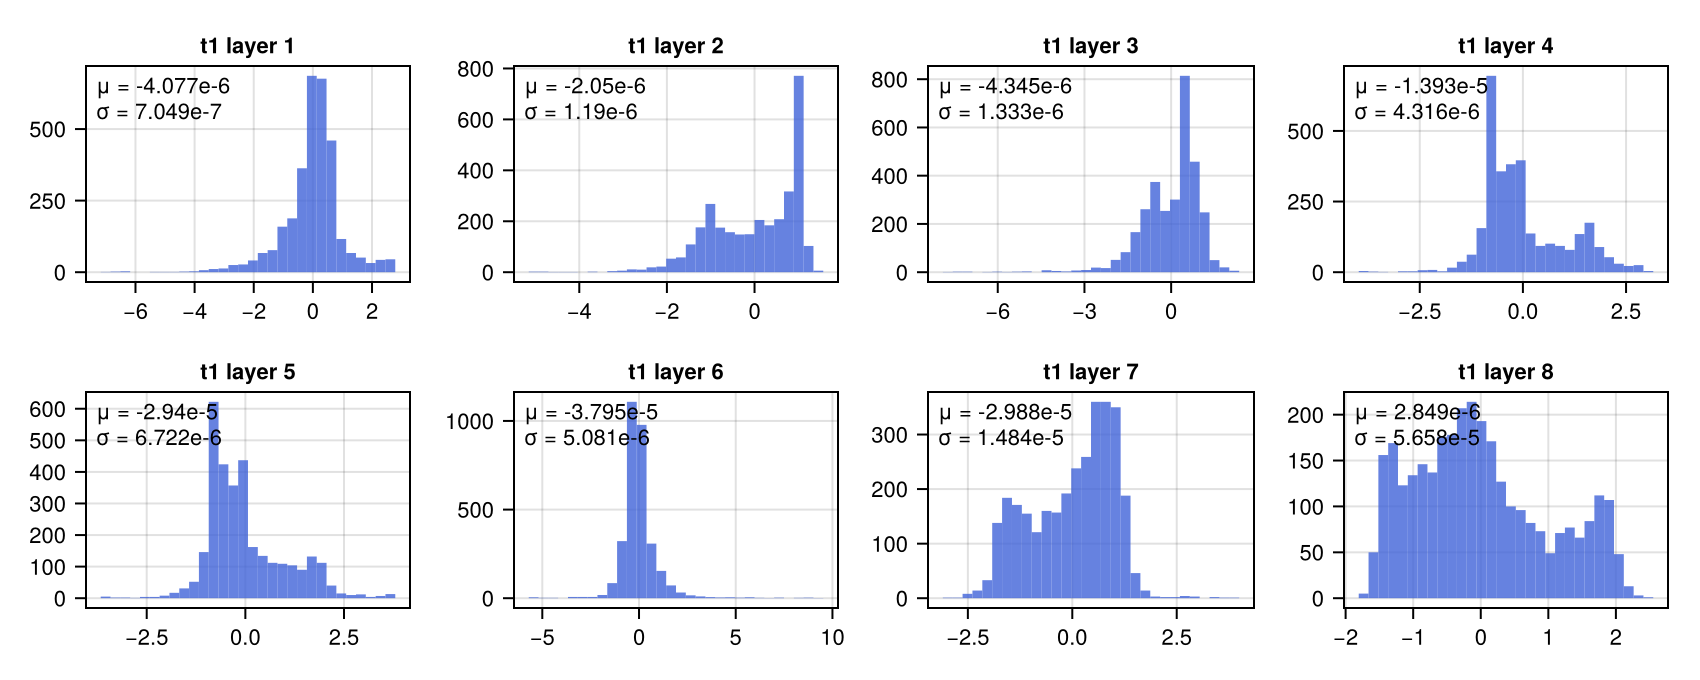

In [30]:
# Planck: Temperature, constant terms
h_t1_planck = plot_hist(coeffs.planck.coeffs, zs.planck, (:t1))

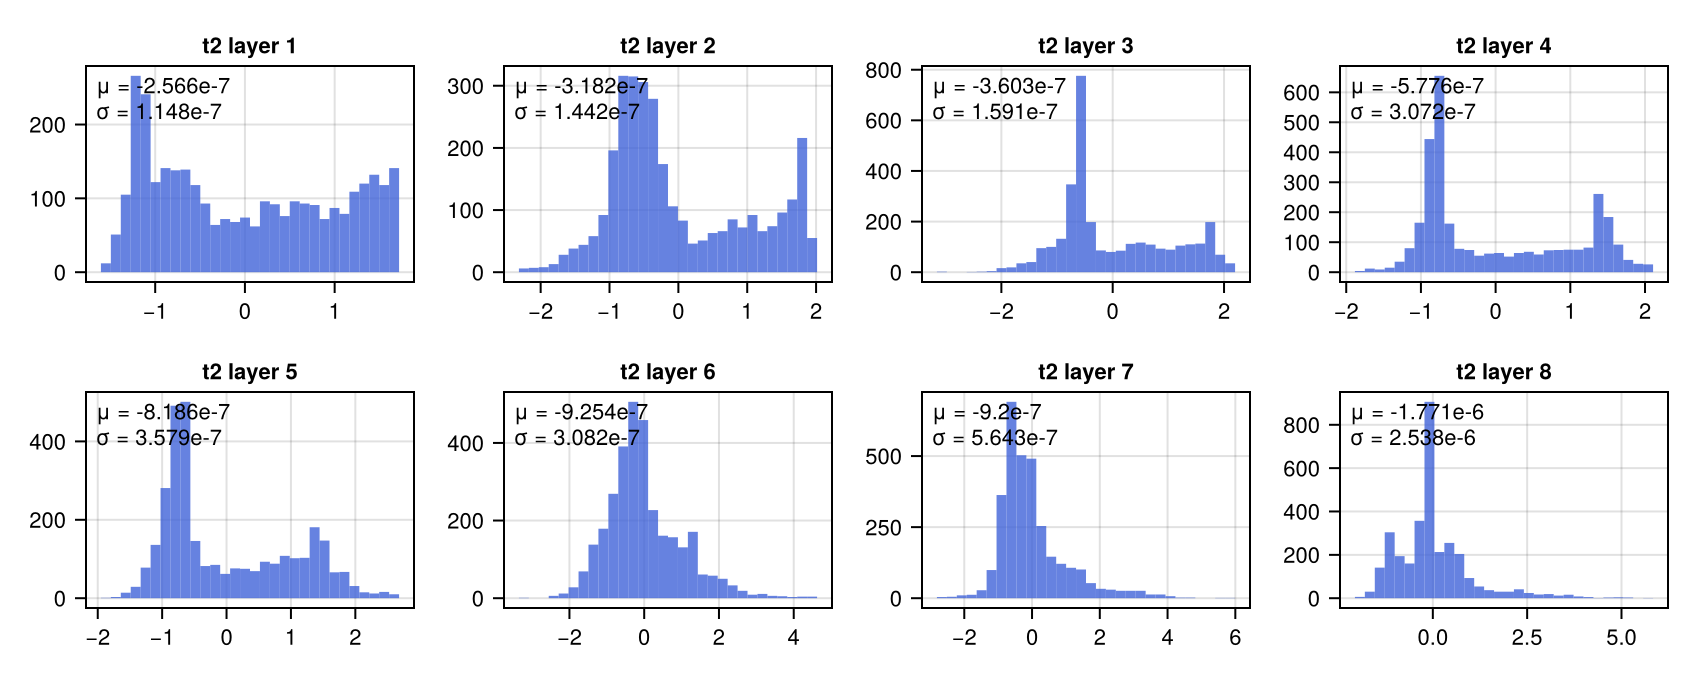

In [31]:
# Linear: Temperature, linear terms
h_t2_linear = plot_hist(coeffs.linear.coeffs, zs.linear, (:t2))

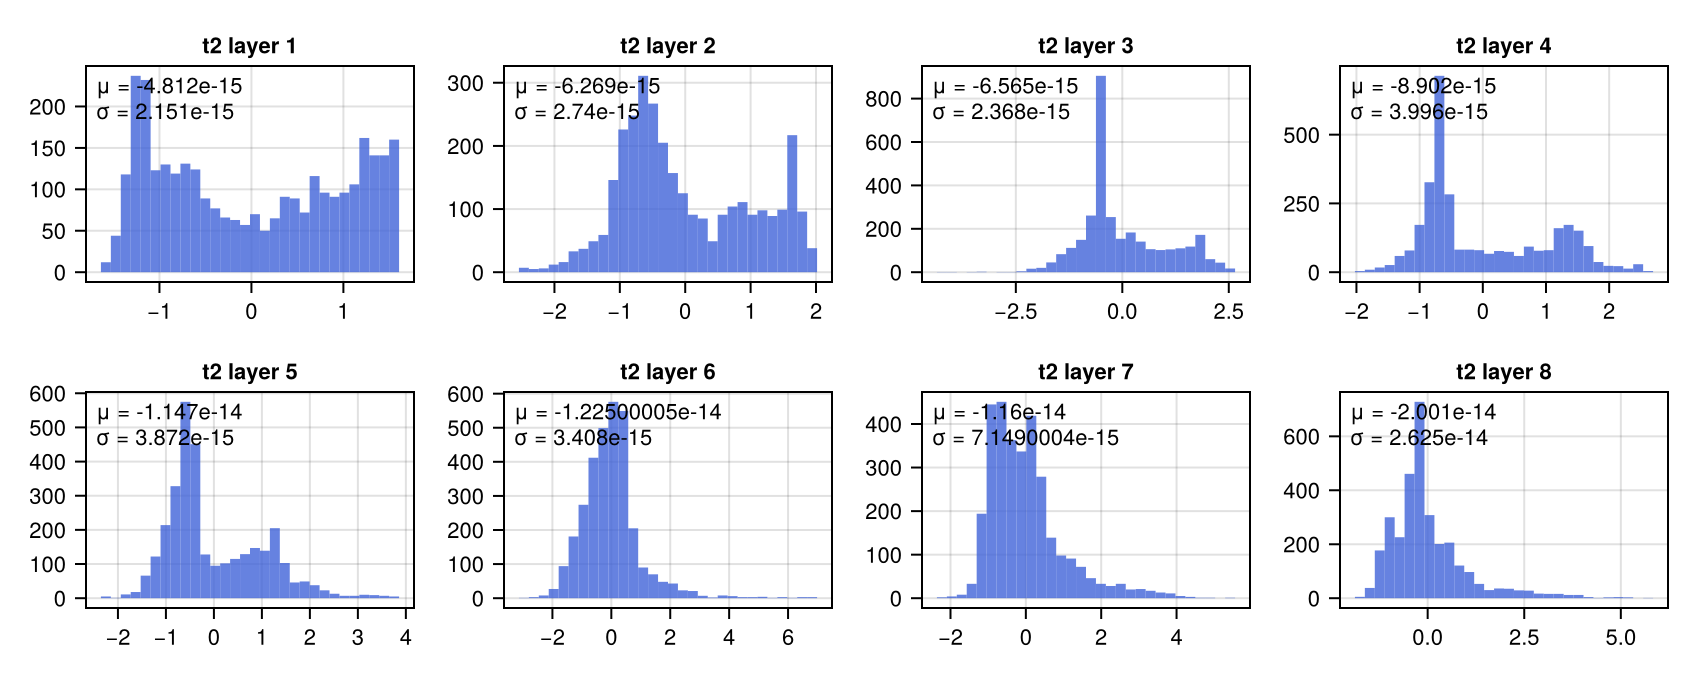

In [32]:
# Planck: Temperature, linear term
h_t2_planck = plot_hist(coeffs.planck.coeffs, zs.planck, (:t2))

#### 2.2.2. Fluxes

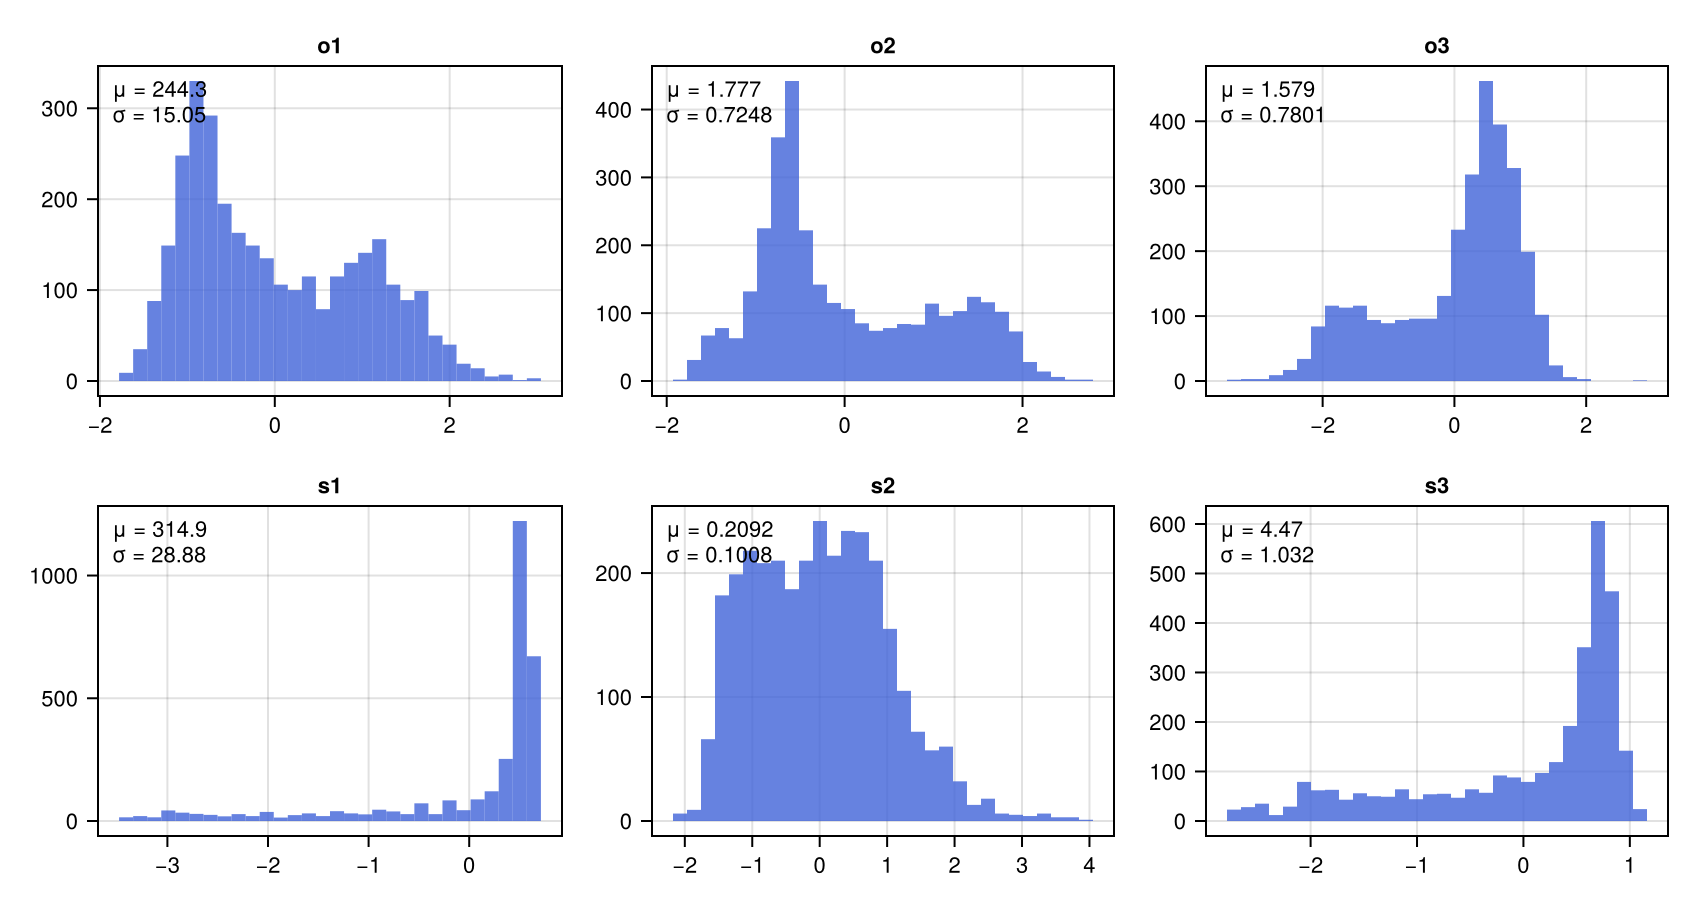

In [33]:
# Linear: Fluxes
h_fluxes_linear = plot_hist(coeffs.linear.coeffs, zs.linear, (:o1, :o2, :o3, :s1, :s2, :s3), style=(;ncols=3))

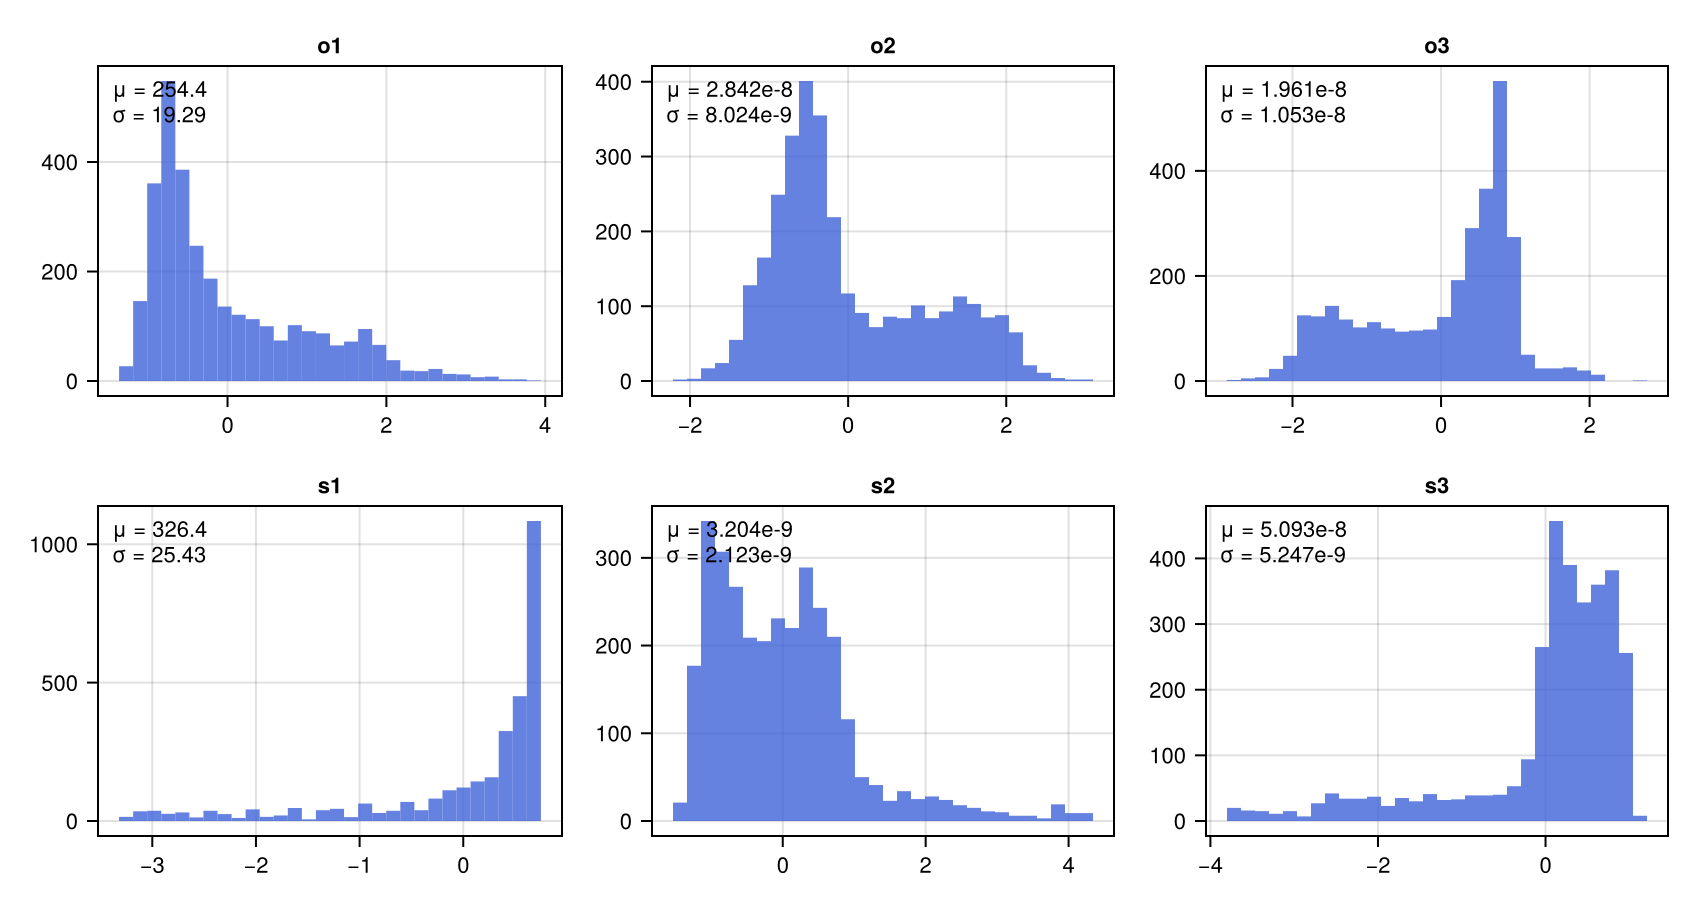

In [34]:
# Planck: Fluxes
h_fluxes_planck = plot_hist(coeffs.planck.coeffs, zs.planck, (:o1, :o2, :o3, :s1, :s2, :s3), style=(;ncols=3))

### 2.3. Save Plots

In [35]:
# Create dir
dir = prepare_out_dir(zscore_dir("OBLW", "default"); name = "plots_distribution", overwrite=true);

In [36]:
# Save IO histograms
save_figure(h_T,            joinpath(dir, "hist_T.png"))
save_figure(h_dT,           joinpath(dir, "hist_dT.png"))
save_figure(h_flux,         joinpath(dir, "hist_flux.png"))
save_figure(h_scalar,       joinpath(dir, "hist_scalar.png"));
save_figure(h_net_fluxes,   joinpath(dir, "hist_net_fluxes.png"));

In [37]:
# Save OF coefficients histograms
save_figure(h_t1_linear,        joinpath(dir, "hist_t1_linear.png"))
save_figure(h_t1_planck,        joinpath(dir, "hist_t1_planck.png"))
save_figure(h_t2_linear,        joinpath(dir, "hist_t2_linear.png"))
save_figure(h_t2_planck,        joinpath(dir, "hist_t2_planck.png"))

save_figure(h_fluxes_linear,    joinpath(dir, "hist_fluxes_linear.png"))
save_figure(h_fluxes_planck,    joinpath(dir, "hist_fluxes_planck.png"))

"C:\\Code\\NeuralLongwave.jl\\data\\zscore\\OBLW\\default\\plots_distribution\\hist_fluxes_planck.png"